
# Retrieval-Augmented Generation (RAG) Lab

This notebook is a hands-on tour of the two halves of a RAG pipeline that people spend the
most time tuning: **chunking** and **retrieval**. Embedding the chunks and asking an LLM to
answer from them is comparatively mechanical once those two choices are made well.

We will:

1. Take a single source document and split it with **six different chunking techniques**
   (fixed-size, fixed-size with overlap, sentence-based, paragraph-based, recursive
   character splitting, and embedding-based semantic chunking).
2. **Embed** the resulting chunks with a sentence-transformer model.
3. Run the same queries through **five retrieval techniques** (TF-IDF, BM25, dense cosine
   similarity, hybrid sparse+dense, MMR for diversity, and cross-encoder re-ranking) and
   compare what each one surfaces.
4. **Visualize** what each strategy is actually doing — where chunk boundaries fall, where
   semantic chunking decides to "cut", how retrieval scores compare, and how MMR trades
   relevance for diversity in embedding space.
5. Wrap up with a discussion of the trade-offs.

> No API keys are required — everything runs locally with `sentence-transformers`,
> `scikit-learn`, and `rank_bm25`.


In [1]:

# --- Core imports -----------------------------------------------------------
import re                       # regex, used for simple word tokenization for BM25/TF-IDF-style matching
import math
import textwrap                 # used to shorten long chunk previews for printing
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches   # for the bi-encoder / cross-encoder schematic diagram

from sklearn.feature_extraction.text import TfidfVectorizer   # lexical (bag-of-words) retrieval
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA                          # for projecting embeddings to 2D for plotting
from rank_bm25 import BM25Okapi                                 # BM25 lexical retrieval
from sentence_transformers import SentenceTransformer, CrossEncoder  # dense embeddings + cross-encoder re-ranker

# NLTK is only used for sentence tokenization (splitting text into sentences).
import nltk
for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)
from nltk.tokenize import sent_tokenize

pd.set_option("display.max_colwidth", 120)   # don't truncate chunk text too aggressively in DataFrames
np.random.seed(0)                             # reproducibility for anything that samples
print("Setup complete.")


Setup complete.



## 1. The source document

A single ~1,300-word article about the search for extraterrestrial life. It has clear
paragraph breaks and section headings, which makes it easy to see how each chunking
technique respects (or ignores) that structure.


In [2]:
DOCUMENT = """The Search for Life Beyond Earth

Introduction

For most of human history, the question of whether we are alone in the universe belonged to
philosophy and religion rather than science. That changed in the twentieth century, when
advances in astronomy, chemistry, and biology gave researchers the tools to ask the question
rigorously. Today, the search for life beyond Earth is a rigorous, well-funded, and rapidly
advancing scientific discipline that touches nearly every branch of the natural sciences. It
spans the study of extremophiles in Earth's harshest environments, the chemistry of interstellar
clouds, the geology of icy moons, and the design of telescopes capable of imaging planets
orbiting distant stars.

The Habitable Zone

Every star radiates energy that warms the planets around it, and for any given star there exists
a range of orbital distances where a rocky planet could sustain liquid water on its surface. This
region is commonly called the habitable zone, or sometimes the "Goldilocks zone," because
conditions there are neither too hot nor too cold. Venus, for example, orbits just inside the
inner edge of our sun's habitable zone and suffered a runaway greenhouse effect that left its
surface hot enough to melt lead. Mars orbits just outside the outer edge and lost most of its
atmosphere billions of years ago, leaving a cold, thin-aired world. Earth, sitting comfortably in
the middle, developed oceans, plate tectonics, and eventually life.

Astronomers have cataloged thousands of exoplanets since the first confirmed detection in 1995,
and a growing fraction of them orbit within their star's habitable zone. Missions like Kepler,
TESS, and the upcoming PLATO mission are designed specifically to find these worlds by watching
for the tiny dip in starlight that occurs when a planet passes in front of its star. Each
transit reveals the planet's size and orbital period, and combined with the mass of the host
star, astronomers can estimate whether the planet's surface temperature would allow liquid water.

Biosignatures and Technosignatures

Finding a planet in the habitable zone is only the first step. The much harder problem is
determining whether life actually exists there. Scientists look for biosignatures, which are
chemical or physical signs that indicate biological activity. Oxygen and methane coexisting in
an atmosphere is one classic example, because the two gases react with each other and would
disappear quickly unless something was continuously replenishing them. Seasonal variations in
atmospheric gases, unusual surface colors consistent with pigments, and even the specific way
light reflects off a planet's surface can all serve as clues.

A related but distinct concept is the technosignature, evidence of technology rather than biology.
Radio transmissions, laser pulses, unusual heat signatures from large structures, or atmospheric
pollutants inconsistent with natural processes would all count as technosignatures. Programs such
as the Search for Extraterrestrial Intelligence, commonly abbreviated SETI, have scanned the sky
for decades listening for artificial radio signals. So far, no confirmed signal has ever been
detected, but the search continues with ever more sensitive instruments and cleverer search
strategies, including efforts to detect optical laser flashes and to analyze exoplanet
atmospheres for industrial byproducts.

Extremophiles and the Limits of Life on Earth

Our best guide to what alien life might look like is the life we already know. Over the past
several decades, biologists have discovered organisms thriving in conditions once thought
completely lethal. Extremophiles live in boiling hydrothermal vents at the bottom of the ocean,
in the acidic runoff of mines, in Antarctic ice cores, and even inside nuclear reactor cooling
systems. Some microbes can survive years of complete desiccation, extreme radiation exposure, or
the near-vacuum and cold of low Earth orbit, as demonstrated by experiments exposing tardigrades
and bacteria directly to space.

These discoveries have radically expanded scientists' sense of where life could plausibly exist
elsewhere in the solar system. If microbial life can thrive in a boiling, sulfurous vent on the
ocean floor, then perhaps similar organisms could survive in the subsurface oceans of Europa or
Enceladus, moons of Jupiter and Saturn respectively, both of which show strong evidence of liquid
water beneath their icy shells, kept warm by tidal heating rather than sunlight.

Ocean Worlds of the Outer Solar System

Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists.
Its icy crust is crisscrossed with reddish-brown fractures, and measurements of its magnetic
field strongly suggest a global saltwater ocean beneath the ice, possibly in contact with a
rocky seafloor where hydrothermal chemistry could support life. NASA's Europa Clipper mission,
launched to study the moon in detail, will map its surface, measure the thickness of its ice
shell, and search for plumes of water vapor erupting from cracks in the crust.

Enceladus, a much smaller moon of Saturn, has already provided direct evidence of such plumes.
The Cassini spacecraft flew through geysers erupting from Enceladus's south pole and detected
water vapor, ice grains, organic molecules, and even molecular hydrogen, a potential energy
source for microbial metabolism. These findings make Enceladus one of the most promising targets
in the search for extant life within our own solar system, despite its small size and distance
from the sun.

Titan, Saturn's largest moon, offers a stranger possibility. Its surface is far too cold for
liquid water, but it hosts lakes and rivers of liquid methane and ethane, along with a thick
nitrogen atmosphere rich in complex organic chemistry. Some researchers have speculated about
exotic, methane-based biochemistries that could theoretically function at Titan's frigid
temperatures, though this remains highly speculative and very different from life as we know it
on Earth.

Mars: The Closest Frontier

Mars remains the most accessible target for direct exploration. Robotic rovers including
Curiosity and Perseverance have found abundant evidence that Mars once had rivers, lakes, and
possibly even an ocean billions of years ago, during a warmer and wetter early period in its
history. Perseverance is specifically caching rock samples in Jezero Crater, an ancient lake bed,
for eventual return to Earth by a future sample-return mission, where laboratories could search
for fossilized microbial biosignatures with a level of precision no rover instrument can match.

Modern Mars is cold and dry, but evidence of intermittent liquid water, in the form of dark
streaks called recurring slope lineae and possible subsurface brine, suggests the story of water
on Mars is not entirely finished. Whether any Martian microbes survived the planet's long decline
into its current arid state is one of the central open questions in astrobiology.

The Role of Spectroscopy

Much of modern biosignature science depends on spectroscopy, the study of how matter absorbs and
emits light at different wavelengths. When starlight passes through or reflects off a planet's
atmosphere, specific wavelengths are absorbed by specific molecules, leaving a chemical
fingerprint in the spectrum. The James Webb Space Telescope, with its large mirror and infrared
instruments, can analyze the atmospheres of some exoplanets in unprecedented detail, searching
for water vapor, carbon dioxide, methane, and other molecules of interest.

Future observatories, including proposed missions like the Habitable Worlds Observatory, aim to
directly image Earth-sized planets around sun-like stars and split their faint light into a
spectrum, hunting for the same oxygen and methane combination that would raise eyebrows if found
on an alien world. Direct imaging is extraordinarily difficult because a planet is many billions
of times fainter than its host star, requiring advanced technology such as coronagraphs and
starshades to block out the star's glare.

Open Questions and the Path Forward

Despite decades of progress, fundamental questions remain unanswered. Scientists still do not
know how common the emergence of life is once the right chemical and environmental conditions
exist, a value sometimes called the abiogenesis rate. They do not know whether complex,
multicellular life is a common outcome of evolution or a rare fluke that happened only once on
Earth. And they do not know whether intelligent, technology-using civilizations are common,
rare, or effectively unique, a puzzle famously captured by the Fermi Paradox, which asks why, if
intelligent life should be common, we have not yet detected any convincing sign of it.

What is clear is that the tools available to researchers keep improving. Sample-return missions,
next-generation space telescopes, submersible probes designed to swim beneath the ice of distant
moons, and increasingly sensitive radio and optical SETI searches are all expanding the scope of
what can be investigated. Whether the answer turns out to be that life is common throughout the
galaxy or vanishingly rare, the search itself continues to reshape our understanding of biology,
chemistry, and our own planet's remarkable and perhaps unusual history.
"""

In [3]:

# Quick sanity check on the raw text before we start slicing it up.
print(DOCUMENT[:600] + " ...")
print()
print(f"Total characters: {len(DOCUMENT)}")
print(f"Total words: {len(DOCUMENT.split())}")


The Search for Life Beyond Earth

Introduction

For most of human history, the question of whether we are alone in the universe belonged to
philosophy and religion rather than science. That changed in the twentieth century, when
advances in astronomy, chemistry, and biology gave researchers the tools to ask the question
rigorously. Today, the search for life beyond Earth is a rigorous, well-funded, and rapidly
advancing scientific discipline that touches nearly every branch of the natural sciences. It
spans the study of extremophiles in Earth's harshest environments, the chemistry of interstel ...

Total characters: 9366
Total words: 1421



## 2. Chunking techniques

A "chunk" is the unit of text we embed and retrieve. Chunk size and boundaries directly
determine retrieval quality: chunks that are too large dilute the embedding with irrelevant
content, while chunks that are too small lose context. We'll implement six common
strategies from scratch so the mechanics are transparent.


In [4]:

@dataclass
class Chunk:
    '''A single chunk of text produced by one of the chunking strategies below.'''
    text: str            # the chunk's text content
    method: str           # which chunking strategy produced it (for later comparison/plots)
    index: int            # its position within that method's output (0-based)
    meta: dict = field(default_factory=dict)   # optional extra info (e.g. start offset)


def show_chunks(chunks, n=3):
    '''Print summary stats for a list of Chunks plus a preview of the first `n`.'''
    lengths = [len(c.text) for c in chunks]
    print(f"{chunks[0].method}: {len(chunks)} chunks "
          f"(avg {np.mean(lengths):.0f} chars, min {min(lengths)}, max {max(lengths)})")
    print("-" * 70)
    for c in chunks[:n]:
        # shorten() collapses newlines/whitespace and truncates so previews stay one line
        preview = textwrap.shorten(c.text.replace("\n", " "), width=160, placeholder=" ...")
        print(f"[{c.index}] {preview}")
    print()


### 2.1 Fixed-size character chunking

The simplest approach: cut the text every `N` characters, no regard for word or sentence boundaries.

In [5]:

def chunk_fixed_size(text, size=400):
    '''Slice `text` into non-overlapping windows of exactly `size` characters.

    Pros: trivial to implement, predictable chunk count/size.
    Cons: will cut words and sentences in half wherever the window boundary happens to fall.
    '''
    chunks = []
    # range(0, len(text), size) gives the start index of each window: 0, size, 2*size, ...
    for i, start in enumerate(range(0, len(text), size)):
        piece = text[start:start + size]
        if piece.strip():                     # skip empty/whitespace-only trailing pieces
            chunks.append(Chunk(piece.strip(), "fixed_size", i))
    return chunks

fixed_chunks = chunk_fixed_size(DOCUMENT, size=400)
show_chunks(fixed_chunks)


fixed_size: 24 chunks (avg 390 chars, min 165, max 400)
----------------------------------------------------------------------
[0] The Search for Life Beyond Earth Introduction For most of human history, the question of whether we are alone in the universe belonged to philosophy and ...
[1] , and rapidly advancing scientific discipline that touches nearly every branch of the natural sciences. It spans the study of extremophiles in Earth's ...
[2] and for any given star there exists a range of orbital distances where a rocky planet could sustain liquid water on its surface. This region is commonly ...



### 2.2 Fixed-size chunking with overlap

Same idea, but consecutive chunks share a sliding-window overlap so a fact split across a boundary still appears whole in at least one chunk.

In [6]:

def chunk_fixed_overlap(text, size=400, overlap=100):
    '''Like chunk_fixed_size, but each new window starts `size - overlap` characters after
    the previous one instead of `size` characters after it — so windows overlap by `overlap`
    characters. This means any sentence near a boundary still appears whole in at least one
    of the two overlapping chunks.
    '''
    chunks = []
    step = size - overlap     # how far the window advances each iteration (< size because of overlap)
    i = 0
    idx = 0
    while i < len(text):
        piece = text[i:i + size]
        if piece.strip():
            chunks.append(Chunk(piece.strip(), "fixed_overlap", idx))
            idx += 1
        i += step              # advance by the smaller step, not the full window size
    return chunks

overlap_chunks = chunk_fixed_overlap(DOCUMENT, size=400, overlap=100)
show_chunks(overlap_chunks)


fixed_overlap: 32 chunks (avg 388 chars, min 65, max 400)
----------------------------------------------------------------------
[0] The Search for Life Beyond Earth Introduction For most of human history, the question of whether we are alone in the universe belonged to philosophy and ...
[1] s to ask the question rigorously. Today, the search for life beyond Earth is a rigorous, well-funded, and rapidly advancing scientific discipline that ...
[2] lar clouds, the geology of icy moons, and the design of telescopes capable of imaging planets orbiting distant stars. The Habitable Zone Every star radiates ...



### 2.3 Sentence-based chunking

Split on sentence boundaries (via NLTK) and greedily pack sentences into chunks up to a target size, so chunk boundaries never fall mid-sentence.

In [7]:

def chunk_by_sentences(text, target_size=400):
    '''Greedily pack whole sentences into a chunk until adding the next sentence would push
    it past `target_size` characters, then start a new chunk. Boundaries always fall between
    sentences, never inside one.
    '''
    sentences = sent_tokenize(text.replace("\n", " "))   # NLTK splits text into a list of sentences
    chunks, current, idx = [], "", 0
    for sent in sentences:
        candidate = (current + " " + sent).strip()
        if len(candidate) > target_size and current:
            # adding this sentence would overflow the target size -> close the current chunk first
            chunks.append(Chunk(current.strip(), "sentence", idx))
            idx += 1
            current = sent                 # start the new chunk with the sentence that didn't fit
        else:
            current = candidate            # still room: keep accumulating sentences
    if current.strip():                    # flush whatever's left after the loop
        chunks.append(Chunk(current.strip(), "sentence", idx))
    return chunks

sentence_chunks = chunk_by_sentences(DOCUMENT, target_size=400)
show_chunks(sentence_chunks)


sentence: 29 chunks (avg 321 chars, min 220, max 396)
----------------------------------------------------------------------
[0] The Search for Life Beyond Earth Introduction For most of human history, the question of whether we are alone in the universe belonged to philosophy and ...
[1] Today, the search for life beyond Earth is a rigorous, well-funded, and rapidly advancing scientific discipline that touches nearly every branch of the ...
[2] The Habitable Zone Every star radiates energy that warms the planets around it, and for any given star there exists a range of orbital distances where a ...



### 2.4 Paragraph-based chunking

Use the document's own structure: one chunk per paragraph (blank-line separated). Respects author intent but produces uneven chunk sizes.

In [8]:

def chunk_by_paragraph(text):
    '''One chunk per paragraph, where paragraphs are separated by a blank line ("\n\n").
    Simple, and respects the author's own structuring of the document, but chunk sizes can
    vary wildly (a one-sentence paragraph vs. a dense multi-sentence one).
    '''
    paras = [p.strip() for p in text.split("\n\n") if p.strip()]   # drop empty splits
    return [Chunk(p, "paragraph", i) for i, p in enumerate(paras)]

paragraph_chunks = chunk_by_paragraph(DOCUMENT)
show_chunks(paragraph_chunks)


paragraph: 25 chunks (avg 373 chars, min 12, max 732)
----------------------------------------------------------------------
[0] The Search for Life Beyond Earth
[1] Introduction
[2] For most of human history, the question of whether we are alone in the universe belonged to philosophy and religion rather than science. That changed in the ...



### 2.5 Recursive character chunking

Popularized by LangChain's `RecursiveCharacterTextSplitter`. Try splitting on the
"biggest" separator first (`\n\n`), and only fall back to a smaller one (`\n`, then `. `,
then a raw character cut) for pieces that are still too large. This tends to produce chunks
that respect paragraph/sentence structure while still honoring a hard size limit.

In [9]:

def recursive_split(text, size=400, separators=("\n\n", "\n", ". ", " ")):
    '''Recursively split `text` on the first separator in `separators` that actually breaks
    it into multiple pieces, then greedily re-merge adjacent pieces back up to `size`
    characters. Any merged piece that is still too big gets recursively split again using
    the *next*, finer-grained separator. This is a structure-aware fallback chain:
    paragraph breaks > line breaks > sentence breaks > raw whitespace.
    '''
    text = text.strip()
    if len(text) <= size or not separators:
        # base case: already small enough, or we've run out of separators to try
        return [text] if text else []

    sep, rest = separators[0], separators[1:]     # try the coarsest remaining separator first
    parts = [p for p in text.split(sep) if p.strip()]
    if len(parts) == 1:
        # this separator didn't actually split anything -> fall back to a finer separator
        return recursive_split(text, size, rest)

    # Greedily re-merge consecutive parts (rejoined with `sep`) as long as they still fit
    # within `size`. This is what keeps e.g. several short sentences together in one chunk
    # instead of emitting one chunk per sentence.
    chunks, current = [], ""
    for part in parts:
        candidate = (current + sep + part) if current else part
        if len(candidate) <= size:
            current = candidate
        else:
            if current:
                # current chunk is as big as it can get; recurse only if it's still oversized
                chunks.extend(recursive_split(current, size, rest) if len(current) > size else [current])
            current = part
    if current:
        chunks.extend(recursive_split(current, size, rest) if len(current) > size else [current])
    return chunks

recursive_texts = recursive_split(DOCUMENT, size=400)
recursive_chunks = [Chunk(t.strip(), "recursive", i) for i, t in enumerate(recursive_texts) if t.strip()]
show_chunks(recursive_chunks)


recursive: 38 chunks (avg 245 chars, min 18, max 394)
----------------------------------------------------------------------
[0] The Search for Life Beyond Earth Introduction
[1] For most of human history, the question of whether we are alone in the universe belonged to philosophy and religion rather than science. That changed in the ...
[2] advancing scientific discipline that touches nearly every branch of the natural sciences. It spans the study of extremophiles in Earth's harshest ...



### 2.6 Semantic (embedding-based) chunking

Embed each sentence, then walk through the document and cut a new chunk whenever the
cosine similarity between consecutive sentences drops below a threshold — i.e. whenever the
topic seems to shift. This is the most "RAG-aware" strategy: boundaries follow meaning
rather than length. It needs the embedding model, so we load it here (and reuse it below
for chunk and query embeddings).

In [10]:

# Small, fast sentence-transformer model (384-dim embeddings). Reused throughout the
# notebook for chunk embeddings, query embeddings, and semantic chunking itself.
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def chunk_semantic(text, embedder, similarity_threshold=0.35, max_chunk_chars=800):
    '''Embed every sentence, then walk through them in order and start a new chunk whenever
    either condition is met:
      1. the cosine similarity between this sentence and the previous one drops below
         `similarity_threshold` (a likely topic change), or
      2. the current chunk has already grown past `max_chunk_chars` (a hard safety cap).
    Otherwise, keep appending the sentence to the current chunk.
    '''
    sentences = sent_tokenize(text.replace("\n", " "))
    # normalize_embeddings=True makes the vectors unit length, so a plain dot product below
    # *is* the cosine similarity (no need to divide by norms).
    sent_embeddings = embedder.encode(sentences, normalize_embeddings=True)

    chunks, current_sents, idx = [], [sentences[0]], 0
    for i in range(1, len(sentences)):
        sim = float(np.dot(sent_embeddings[i - 1], sent_embeddings[i]))   # similarity to previous sentence
        joined_len = len(" ".join(current_sents))
        if sim < similarity_threshold or joined_len > max_chunk_chars:
            # topic shifted (low similarity) or chunk got too long -> close it and start fresh
            chunks.append(Chunk(" ".join(current_sents).strip(), "semantic", idx))
            idx += 1
            current_sents = [sentences[i]]
        else:
            current_sents.append(sentences[i])   # still on-topic: keep growing the chunk
    if current_sents:
        chunks.append(Chunk(" ".join(current_sents).strip(), "semantic", idx))
    return chunks

semantic_chunks = chunk_semantic(DOCUMENT, embedder)
show_chunks(semantic_chunks)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

semantic: 22 chunks (avg 424 chars, min 60, max 927)
----------------------------------------------------------------------
[0] The Search for Life Beyond Earth Introduction For most of human history, the question of whether we are alone in the universe belonged to philosophy and ...
[1] This region is commonly called the habitable zone, or sometimes the "Goldilocks zone," because conditions there are neither too hot nor too cold. Venus, for ...
[2] Astronomers have cataloged thousands of exoplanets since the first confirmed detection in 1995, and a growing fraction of them orbit within their star's ...



**Visual: where does semantic chunking decide to cut?** The line below is the sentence-to-sentence similarity as we walk through the document. Every time it dips below the red threshold line, a new chunk starts (marked with a vertical dashed line).

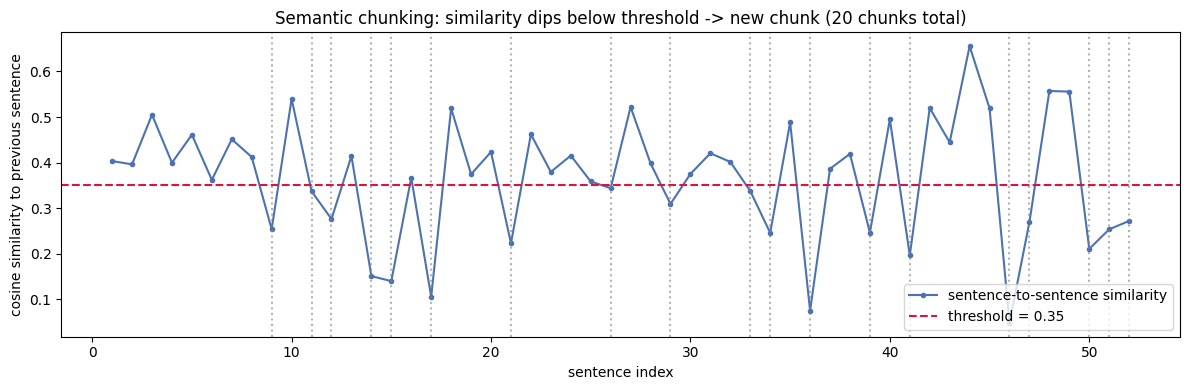

In [11]:

# Recompute the sentence-level similarities just for plotting (same logic as chunk_semantic).
sentences_for_plot = sent_tokenize(DOCUMENT.replace("\n", " "))
sent_embeds_for_plot = embedder.encode(sentences_for_plot, normalize_embeddings=True)
sims = [float(np.dot(sent_embeds_for_plot[i - 1], sent_embeds_for_plot[i]))
        for i in range(1, len(sentences_for_plot))]

threshold = 0.35
cut_positions = [i + 1 for i, s in enumerate(sims) if s < threshold]   # sentence index where a new chunk starts

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(sentences_for_plot)), sims, marker="o", markersize=3,
        color="#4C72B0", label="sentence-to-sentence similarity")
ax.axhline(threshold, color="crimson", linestyle="--", label=f"threshold = {threshold}")
for cp in cut_positions:
    ax.axvline(cp, color="gray", linestyle=":", alpha=0.6)
ax.set_xlabel("sentence index")
ax.set_ylabel("cosine similarity to previous sentence")
ax.set_title(f"Semantic chunking: similarity dips below threshold -> new chunk "
             f"({len(cut_positions) + 1} chunks total)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 2.7 Comparing the six strategies

In [12]:

all_chunk_sets = {
    "fixed_size": fixed_chunks,
    "fixed_overlap": overlap_chunks,
    "sentence": sentence_chunks,
    "paragraph": paragraph_chunks,
    "recursive": recursive_chunks,
    "semantic": semantic_chunks,
}

# One row of summary statistics per chunking method.
summary = pd.DataFrame([
    {
        "method": name,
        "n_chunks": len(chunks),
        "avg_chars": round(np.mean([len(c.text) for c in chunks]), 1),
        "min_chars": min(len(c.text) for c in chunks),
        "max_chars": max(len(c.text) for c in chunks),
        "std_chars": round(np.std([len(c.text) for c in chunks]), 1),   # spread = how uneven chunk sizes are
    }
    for name, chunks in all_chunk_sets.items()
])
summary


,method,n_chunks,avg_chars,min_chars,max_chars,std_chars
0,fixed_size,24,390.0,165,400,46.9
1,fixed_overlap,32,388.2,65,400,58.4
2,sentence,29,321.4,220,396,50.8
3,paragraph,25,372.7,12,732,267.8
4,recursive,38,244.9,18,394,136.9
5,semantic,22,424.0,60,927,267.6


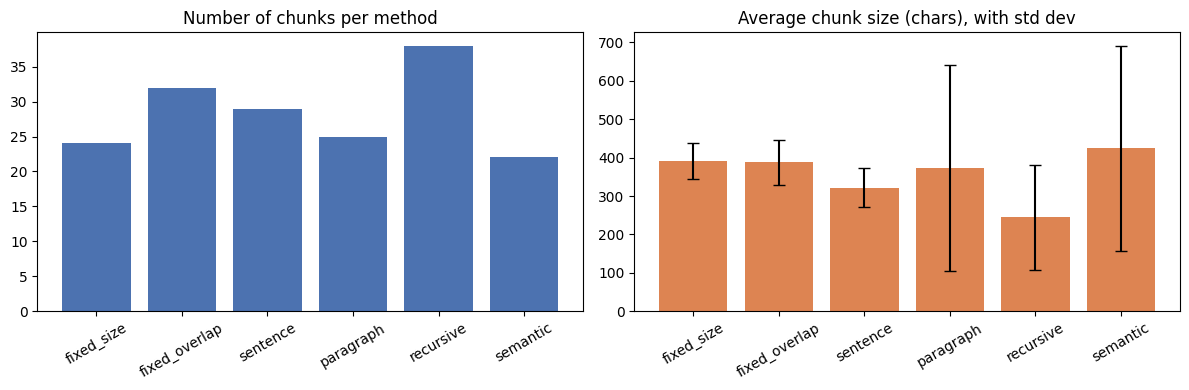

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(summary["method"], summary["n_chunks"], color="#4C72B0")
axes[0].set_title("Number of chunks per method")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(summary["method"], summary["avg_chars"], yerr=summary["std_chars"],
            color="#DD8452", capsize=4)
axes[1].set_title("Average chunk size (chars), with std dev")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**Visual: where do chunk boundaries actually fall in the document?** Each row below is one chunking method; each colored segment is one chunk, positioned at its character offset in the original text. This makes it easy to see uniform vs. structure-following boundaries at a glance.

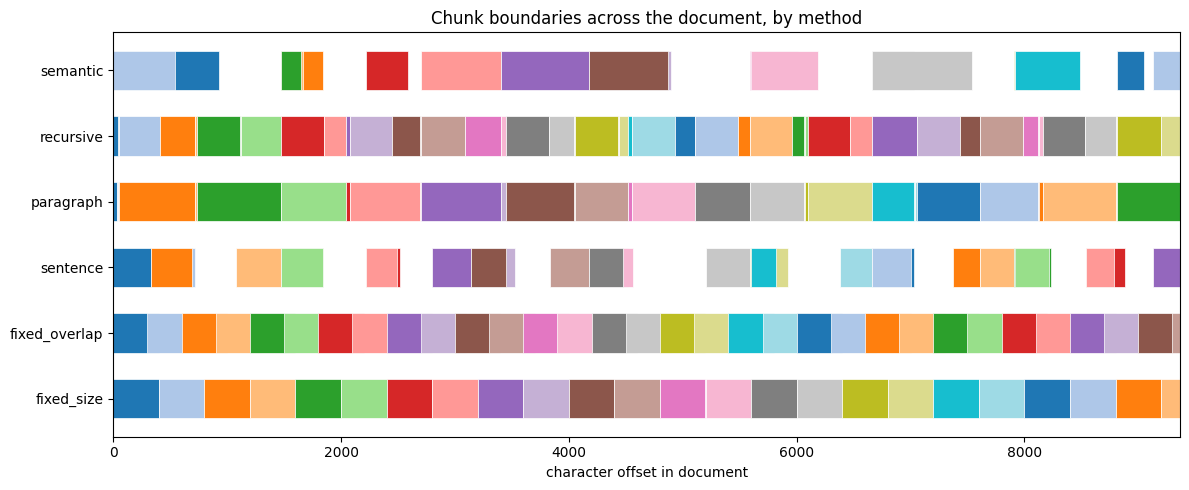

In [14]:

# Build a "boundary map": for each method, find where each chunk starts in the ORIGINAL
# document text (via str.find, walking forward so repeated text doesn't confuse the search),
# then draw one horizontal bar per chunk at that (start, length) position.
fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.get_cmap("tab20")

for row, (method, chunks) in enumerate(all_chunk_sets.items()):
    search_from = 0
    for i, c in enumerate(chunks):
        start = DOCUMENT.find(c.text[:40], search_from)   # locate this chunk's start offset
        if start == -1:
            start = search_from   # fallback if an exact match isn't found (e.g. stripped whitespace)
        length = len(c.text)
        ax.barh(row, length, left=start, height=0.6, color=cmap(i % 20), edgecolor="white", linewidth=0.5)
        search_from = start + 1

ax.set_yticks(range(len(all_chunk_sets)))
ax.set_yticklabels(all_chunk_sets.keys())
ax.set_xlabel("character offset in document")
ax.set_title("Chunk boundaries across the document, by method")
ax.set_xlim(0, len(DOCUMENT))
plt.tight_layout()
plt.show()



**Observations:**

- `fixed_size` and `fixed_overlap` produce very uniform chunk sizes (visible as evenly-sized
  segments above) but will happily cut a sentence, or even a word, in half.
- `paragraph` chunks are the most uneven — some paragraphs are one sentence, others are a
  full section — but each chunk is a coherent unit of thought.
- `sentence` and `recursive` land in between: bounded size, but boundaries always fall on
  a natural sentence/paragraph break.
- `semantic` chunk count and size depend entirely on how "topically choppy" the text is,
  as the similarity-curve plot above shows directly — a document that changes subject often
  will produce more, smaller chunks.



## 3. Embedding the chunks

We use the `all-MiniLM-L6-v2` sentence-transformer (384-dim embeddings) — small, fast, and
good enough for a local demo. Each chunking strategy gets its own embedding matrix so we can
retrieve from any of them.


In [15]:

def embed_chunks(chunks, embedder):
    '''Encode a list of Chunks into a (n_chunks, 384) matrix of L2-normalized embeddings.
    Normalizing means a plain dot product between two rows equals cosine similarity.
    '''
    texts = [c.text for c in chunks]
    return embedder.encode(texts, normalize_embeddings=True, show_progress_bar=False)

# Embed every chunking strategy's output separately, so we can compare retrieval across them.
embeddings_by_method = {name: embed_chunks(chunks, embedder) for name, chunks in all_chunk_sets.items()}
for name, emb in embeddings_by_method.items():
    print(f"{name:>15s}: {emb.shape}")


     fixed_size: (24, 384)
  fixed_overlap: (32, 384)
       sentence: (29, 384)
      paragraph: (25, 384)
      recursive: (38, 384)
       semantic: (22, 384)



## 4. Retrieval techniques

For the retrieval comparisons we'll standardize on **one** chunk set — `recursive`, a good
general-purpose default — so the differences we see are due to the *retrieval* method, not
the chunking method. (Section 5 then puts both axes together.)


In [16]:

# Fix the chunk set used for every retrieval demo below, so comparisons are apples-to-apples.
RETRIEVAL_CHUNKS = all_chunk_sets["recursive"]
RETRIEVAL_TEXTS = [c.text for c in RETRIEVAL_CHUNKS]
RETRIEVAL_EMBEDDINGS = embeddings_by_method["recursive"]

def print_results(query, results):
    '''Pretty-print a ranked list of (chunk_index, score) results for a query.'''
    print(f'Query: "{query}"')
    print("-" * 70)
    for rank, (idx, score) in enumerate(results, 1):
        preview = textwrap.shorten(RETRIEVAL_TEXTS[idx].replace("\n", " "), width=140, placeholder=" ...")
        print(f"{rank}. [chunk {idx}, score={score:.3f}] {preview}")
    print()

# Three test queries we'll reuse across every retrieval method for a like-for-like comparison.
QUERIES = [
    "How do scientists detect water on Europa and Enceladus?",
    "What is a biosignature?",
    "Why is Mars a target for finding past life?",
]


### 4.1 Lexical retrieval: TF-IDF cosine similarity

Classic bag-of-words retrieval: represent each chunk and the query as TF-IDF vectors and rank by cosine similarity. Fast, needs no model, but only matches literal word overlap (no synonyms).

In [17]:

# TF-IDF: each chunk becomes a sparse vector where each dimension is a vocabulary word,
# weighted by how frequent it is in that chunk (TF) discounted by how common it is across
# ALL chunks (IDF) -- so rare, distinctive words matter more than common ones.
tfidf_vectorizer = TfidfVectorizer(stop_words="english")   # drop "the", "and", etc.
tfidf_matrix = tfidf_vectorizer.fit_transform(RETRIEVAL_TEXTS)

def retrieve_tfidf(query, k=3):
    query_vec = tfidf_vectorizer.transform([query])                 # project query into the same vector space
    sims = cosine_similarity(query_vec, tfidf_matrix)[0]             # similarity to every chunk
    top = np.argsort(-sims)[:k]                                      # indices of the k highest scores
    return [(int(i), float(sims[i])) for i in top]

for q in QUERIES:
    print_results(q, retrieve_tfidf(q))


Query: "How do scientists detect water on Europa and Enceladus?"
----------------------------------------------------------------------
1. [chunk 21, score=0.251] Enceladus, a much smaller moon of Saturn, has already provided direct evidence of such plumes. The Cassini spacecraft flew through ...
2. [chunk 16, score=0.232] These discoveries have radically expanded scientists' sense of where life could plausibly exist elsewhere in the solar system. If ...
3. [chunk 19, score=0.203] Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists. Its icy crust is crisscrossed with ...

Query: "What is a biosignature?"
----------------------------------------------------------------------
1. [chunk 29, score=0.178] Much of modern biosignature science depends on spectroscopy, the study of how matter absorbs and emits light at different wavelengths. ...
2. [chunk 0, score=0.000] The Search for Life Beyond Earth Introduction
3. [chunk 2, score=0.000] advancing sc

### 4.2 Lexical retrieval: BM25

BM25 improves on raw TF-IDF with term-frequency saturation and document-length normalization — the standard baseline in most production search/retrieval systems (e.g. Elasticsearch).

In [18]:

# BM25 needs the corpus pre-tokenized into lists of words (not a sparse matrix like TF-IDF).
tokenized_corpus = [re.findall(r"\w+", t.lower()) for t in RETRIEVAL_TEXTS]
bm25 = BM25Okapi(tokenized_corpus)

def retrieve_bm25(query, k=3):
    tokenized_query = re.findall(r"\w+", query.lower())
    scores = bm25.get_scores(tokenized_query)   # BM25 score per chunk (higher = more relevant)
    top = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i])) for i in top]

for q in QUERIES:
    print_results(q, retrieve_bm25(q))


Query: "How do scientists detect water on Europa and Enceladus?"
----------------------------------------------------------------------
1. [chunk 34, score=8.720] Despite decades of progress, fundamental questions remain unanswered. Scientists still do not know how common the emergence of life is ...
2. [chunk 16, score=7.468] These discoveries have radically expanded scientists' sense of where life could plausibly exist elsewhere in the solar system. If ...
3. [chunk 21, score=5.954] Enceladus, a much smaller moon of Saturn, has already provided direct evidence of such plumes. The Cassini spacecraft flew through ...

Query: "What is a biosignature?"
----------------------------------------------------------------------
1. [chunk 36, score=4.298] What is clear is that the tools available to researchers keep improving. Sample-return missions, next-generation space telescopes, ...
2. [chunk 29, score=2.912] Much of modern biosignature science depends on spectroscopy, the study of how mat

### 4.3 Dense retrieval: embedding cosine similarity

Embed the query with the same sentence-transformer and rank chunks by cosine similarity in embedding space. Captures semantic/paraphrase matches that lexical methods miss (e.g. "water on Europa" matching a chunk about "subsurface ocean").

In [19]:

def retrieve_dense(query, k=3):
    query_emb = embedder.encode([query], normalize_embeddings=True)[0]
    # Embeddings are normalized, so a matrix-vector dot product gives cosine similarity
    # to every chunk in one shot (no explicit loop needed).
    sims = RETRIEVAL_EMBEDDINGS @ query_emb
    top = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i])) for i in top]

for q in QUERIES:
    print_results(q, retrieve_dense(q))


Query: "How do scientists detect water on Europa and Enceladus?"
----------------------------------------------------------------------
1. [chunk 19, score=0.614] Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists. Its icy crust is crisscrossed with ...
2. [chunk 16, score=0.545] These discoveries have radically expanded scientists' sense of where life could plausibly exist elsewhere in the solar system. If ...
3. [chunk 20, score=0.498] launched to study the moon in detail, will map its surface, measure the thickness of its ice shell, and search for plumes of water vapor ...

Query: "What is a biosignature?"
----------------------------------------------------------------------
1. [chunk 8, score=0.724] Biosignatures and Technosignatures
2. [chunk 11, score=0.440] A related but distinct concept is the technosignature, evidence of technology rather than biology. Radio transmissions, laser pulses, ...
3. [chunk 27, score=0.405] for eventual retu

### 4.4 Hybrid retrieval: BM25 + dense

Combine both signals: min-max normalize each score to [0, 1] and take a weighted sum. This tends to be more robust than either method alone — lexical for exact keyword/name matches, dense for semantic paraphrase matches.

In [20]:

def _normalize(scores):
    '''Min-max scale a score array to [0, 1] so BM25 scores (unbounded) and cosine
    similarities ([-1, 1] in theory) can be combined on a comparable scale.'''
    scores = np.array(scores, dtype=float)
    if scores.max() == scores.min():   # avoid divide-by-zero if every score is identical
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

def retrieve_hybrid(query, k=3, alpha=0.5):
    '''alpha controls the blend: alpha=1.0 is pure dense retrieval, alpha=0.0 is pure BM25.'''
    tokenized_query = re.findall(r"\w+", query.lower())
    bm25_scores = _normalize(bm25.get_scores(tokenized_query))

    query_emb = embedder.encode([query], normalize_embeddings=True)[0]
    dense_scores = _normalize(RETRIEVAL_EMBEDDINGS @ query_emb)

    combined = alpha * dense_scores + (1 - alpha) * bm25_scores   # weighted sum of both signals
    top = np.argsort(-combined)[:k]
    return [(int(i), float(combined[i])) for i in top]

for q in QUERIES:
    print_results(q, retrieve_hybrid(q, alpha=0.5))


Query: "How do scientists detect water on Europa and Enceladus?"
----------------------------------------------------------------------
1. [chunk 16, score=0.873] These discoveries have radically expanded scientists' sense of where life could plausibly exist elsewhere in the solar system. If ...
2. [chunk 19, score=0.822] Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists. Its icy crust is crisscrossed with ...
3. [chunk 21, score=0.732] Enceladus, a much smaller moon of Saturn, has already provided direct evidence of such plumes. The Cassini spacecraft flew through ...

Query: "What is a biosignature?"
----------------------------------------------------------------------
1. [chunk 29, score=0.590] Much of modern biosignature science depends on spectroscopy, the study of how matter absorbs and emits light at different wavelengths. ...
2. [chunk 36, score=0.544] What is clear is that the tools available to researchers keep improving. Sample-ret

**Visual: how do the four scoring methods rank the same chunks?** For one query, this compares the (normalized) score each method assigns to its own top-3 chunks.

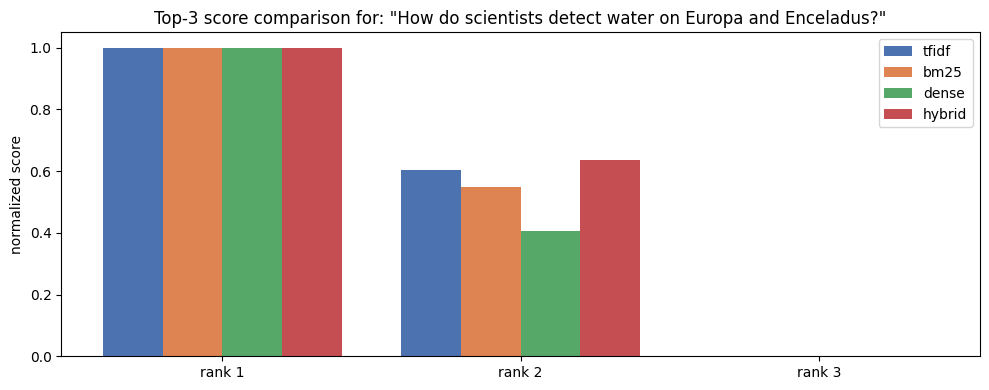

In [21]:

compare_query = QUERIES[0]
methods = {
    "tfidf": retrieve_tfidf,
    "bm25": retrieve_bm25,
    "dense": retrieve_dense,
    "hybrid": retrieve_hybrid,
}

fig, ax = plt.subplots(figsize=(10, 4))
width = 0.2
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for offset, ((name, fn), color) in enumerate(zip(methods.items(), colors)):
    results = fn(compare_query, k=3)
    scores = _normalize([s for _, s in results])   # normalize within-method so bars are comparable
    xs = np.arange(3) + offset * width
    ax.bar(xs, scores, width=width, label=name, color=color)

ax.set_xticks(np.arange(3) + width * 1.5)
ax.set_xticklabels(["rank 1", "rank 2", "rank 3"])
ax.set_ylabel("normalized score")
ax.set_title(f'Top-3 score comparison for: "{compare_query}"')
ax.legend()
plt.tight_layout()
plt.show()


### 4.5 Maximal Marginal Relevance (MMR): diversity-aware retrieval

Pure similarity ranking can return several near-duplicate chunks. MMR iteratively picks the next chunk that balances query relevance against redundancy with what's already been selected — useful when you want broad coverage of a topic rather than five near-identical passages.

In [22]:

def retrieve_mmr(query, k=3, lambda_mult=0.5, fetch_k=10):
    '''Maximal Marginal Relevance. First fetch a candidate pool of the `fetch_k` most
    query-similar chunks, then greedily select `k` of them one at a time: each pick
    maximizes  lambda * relevance_to_query  -  (1 - lambda) * max_similarity_to_already_selected.
    lambda_mult=1.0 reduces to plain top-k similarity; lower values favor diversity more.
    '''
    query_emb = embedder.encode([query], normalize_embeddings=True)[0]
    sims_to_query = RETRIEVAL_EMBEDDINGS @ query_emb
    candidate_idx = list(np.argsort(-sims_to_query)[:fetch_k])   # restrict MMR to a plausible shortlist

    selected = []
    while candidate_idx and len(selected) < k:
        if not selected:
            best = max(candidate_idx, key=lambda i: sims_to_query[i])   # first pick: just most relevant
        else:
            def mmr_score(i):
                # redundancy = how similar candidate i is to the *closest* chunk already picked
                redundancy = max(RETRIEVAL_EMBEDDINGS[i] @ RETRIEVAL_EMBEDDINGS[j] for j in selected)
                return lambda_mult * sims_to_query[i] - (1 - lambda_mult) * redundancy
            best = max(candidate_idx, key=mmr_score)
        selected.append(best)
        candidate_idx.remove(best)
    return [(int(i), float(sims_to_query[i])) for i in selected]

for q in QUERIES:
    print_results(q, retrieve_mmr(q, lambda_mult=0.5))


Query: "How do scientists detect water on Europa and Enceladus?"
----------------------------------------------------------------------
1. [chunk 19, score=0.614] Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists. Its icy crust is crisscrossed with ...
2. [chunk 12, score=0.401] for decades listening for artificial radio signals. So far, no confirmed signal has ever been detected, but the search continues with ...
3. [chunk 21, score=0.477] Enceladus, a much smaller moon of Saturn, has already provided direct evidence of such plumes. The Cassini spacecraft flew through ...

Query: "What is a biosignature?"
----------------------------------------------------------------------
1. [chunk 8, score=0.724] Biosignatures and Technosignatures
2. [chunk 34, score=0.317] Despite decades of progress, fundamental questions remain unanswered. Scientists still do not know how common the emergence of life is ...
3. [chunk 27, score=0.405] for eventual retur

Query: "Why is Mars a target for finding past life?"
----------------------------------------------------------------------
1. [chunk 26, score=0.556] Mars remains the most accessible target for direct exploration. Robotic rovers including Curiosity and Perseverance have found abundant ...
2. [chunk 22, score=0.484] in the search for extant life within our own solar system, despite its small size and distance from the sun.
3. [chunk 5, score=0.532] inner edge of our sun's habitable zone and suffered a runaway greenhouse effect that left its surface hot enough to melt lead. Mars ...



**Visual: MMR vs. plain top-k in embedding space.** We project all chunk embeddings to 2D with PCA and highlight the query, the plain top-3 (most similar, possibly redundant) chunks, and the MMR top-3 (relevant but spread out).

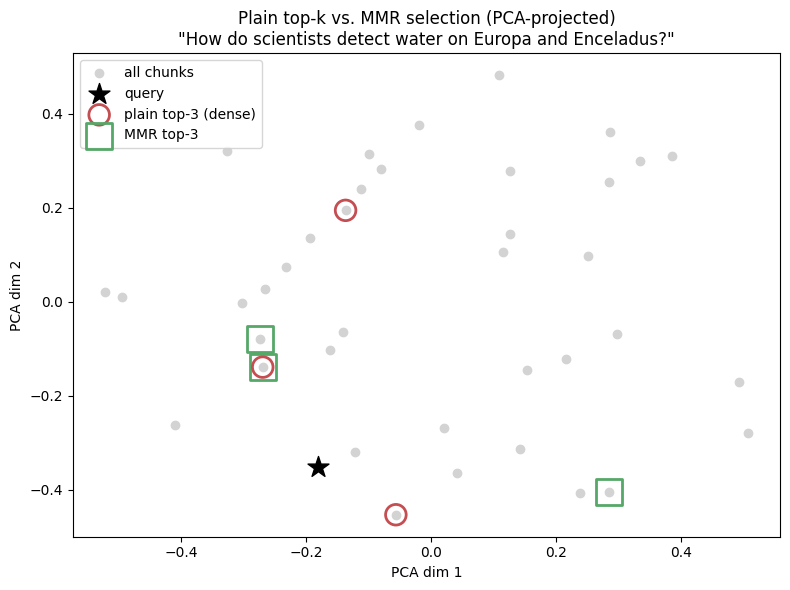

Plain top-3 chunk indices: [19, 16, 20]
MMR   top-3 chunk indices: [19, 12, 21]


In [23]:

mmr_query = QUERIES[0]
query_emb = embedder.encode([mmr_query], normalize_embeddings=True)[0]

# Project the 384-dim chunk embeddings (plus the query) down to 2D purely for visualization.
pca = PCA(n_components=2, random_state=0)
all_points = np.vstack([RETRIEVAL_EMBEDDINGS, query_emb])
coords_2d = pca.fit_transform(all_points)
chunk_coords, query_coord = coords_2d[:-1], coords_2d[-1]

plain_top3 = [i for i, _ in retrieve_dense(mmr_query, k=3)]
mmr_top3 = [i for i, _ in retrieve_mmr(mmr_query, k=3, lambda_mult=0.5)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(chunk_coords[:, 0], chunk_coords[:, 1], color="lightgray", label="all chunks", zorder=1)
ax.scatter(*query_coord, color="black", marker="*", s=250, label="query", zorder=4)
ax.scatter(chunk_coords[plain_top3, 0], chunk_coords[plain_top3, 1],
           facecolors="none", edgecolors="#C44E52", s=220, linewidths=2,
           label="plain top-3 (dense)", zorder=3)
ax.scatter(chunk_coords[mmr_top3, 0], chunk_coords[mmr_top3, 1],
           facecolors="none", edgecolors="#55A868", s=350, linewidths=2, marker="s",
           label="MMR top-3", zorder=2)
ax.set_title(f'Plain top-k vs. MMR selection (PCA-projected)\n"{mmr_query}"')
ax.legend(loc="best")
ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
plt.tight_layout()
plt.show()
print(f"Plain top-3 chunk indices: {plain_top3}")
print(f"MMR   top-3 chunk indices: {mmr_top3}")


### 4.6 Cross-encoder re-ranking

Bi-encoder retrieval (TF-IDF, BM25, dense) scores the query and each chunk *independently*,
which is fast but approximate. A cross-encoder instead reads the query and a candidate chunk
*together* and outputs a relevance score directly — much more accurate, but too slow to run
over an entire corpus. The standard pattern: use a cheap retriever to fetch a shortlist (here,
dense retrieval, top 10), then re-rank that shortlist with the cross-encoder.

**Visual: bi-encoder vs. cross-encoder architecture.** A bi-encoder embeds the query and each chunk *separately* (so chunk embeddings can be precomputed once and reused for every query) and compares vectors afterward. A cross-encoder feeds the query and chunk *together* through one model, letting it directly attend between the two texts — more accurate, but it must re-run the full model for every (query, chunk) pair, so it can't be precomputed.

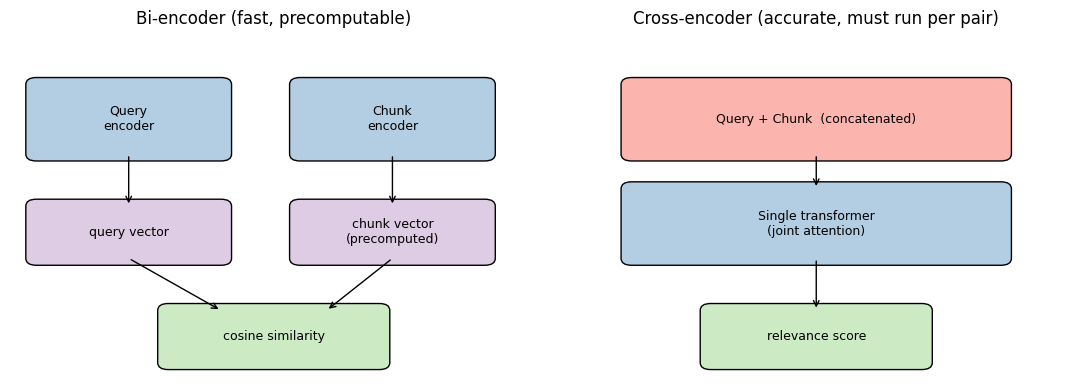

In [24]:

# A purely schematic diagram (boxes + arrows), not data-driven -- just to make the
# architectural difference between bi-encoders and cross-encoders concrete.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

def draw_box(ax, xy, w, h, text, color):
    ax.add_patch(mpatches.FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02",
                                          facecolor=color, edgecolor="black"))
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha="center", va="center", fontsize=9)

# --- Bi-encoder: separate towers, embeddings compared after the fact ---
ax = axes[0]
draw_box(ax, (0.05, 0.65), 0.35, 0.2, "Query\nencoder", "#B3CDE3")
draw_box(ax, (0.55, 0.65), 0.35, 0.2, "Chunk\nencoder", "#B3CDE3")
draw_box(ax, (0.05, 0.35), 0.35, 0.15, "query vector", "#DECBE4")
draw_box(ax, (0.55, 0.35), 0.35, 0.15, "chunk vector\n(precomputed)", "#DECBE4")
draw_box(ax, (0.3, 0.05), 0.4, 0.15, "cosine similarity", "#CCEBC5")
for x0, y0, x1, y1 in [(0.225, 0.65, 0.225, 0.5), (0.725, 0.65, 0.725, 0.5),
                       (0.225, 0.35, 0.4, 0.2), (0.725, 0.35, 0.6, 0.2)]:
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->"))
ax.set_title("Bi-encoder (fast, precomputable)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

# --- Cross-encoder: one model reads query+chunk together ---
ax = axes[1]
draw_box(ax, (0.15, 0.65), 0.7, 0.2, "Query + Chunk  (concatenated)", "#FBB4AE")
draw_box(ax, (0.15, 0.35), 0.7, 0.2, "Single transformer\n(joint attention)", "#B3CDE3")
draw_box(ax, (0.3, 0.05), 0.4, 0.15, "relevance score", "#CCEBC5")
ax.annotate("", xy=(0.5, 0.55), xytext=(0.5, 0.65), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.5, 0.2), xytext=(0.5, 0.35), arrowprops=dict(arrowstyle="->"))
ax.set_title("Cross-encoder (accurate, must run per pair)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

plt.tight_layout()
plt.show()


In [25]:

# Load the cross-encoder once; it will be reused for every re-ranking call below.
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def retrieve_rerank(query, k=3, fetch_k=10):
    shortlist = retrieve_dense(query, k=fetch_k)                       # cheap first pass (bi-encoder)
    pairs = [(query, RETRIEVAL_TEXTS[idx]) for idx, _ in shortlist]    # (query, chunk) pairs for the cross-encoder
    rerank_scores = cross_encoder.predict(pairs)                       # one joint forward pass per pair
    order = np.argsort(-rerank_scores)[:k]                             # re-sort the shortlist by the new scores
    return [(shortlist[i][0], float(rerank_scores[i])) for i in order]

for q in QUERIES:
    print_results(q, retrieve_rerank(q))


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Query: "How do scientists detect water on Europa and Enceladus?"
----------------------------------------------------------------------
1. [chunk 21, score=3.449] Enceladus, a much smaller moon of Saturn, has already provided direct evidence of such plumes. The Cassini spacecraft flew through ...
2. [chunk 19, score=0.482] Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists. Its icy crust is crisscrossed with ...
3. [chunk 16, score=0.448] These discoveries have radically expanded scientists' sense of where life could plausibly exist elsewhere in the solar system. If ...

Query: "What is a biosignature?"
----------------------------------------------------------------------
1. [chunk 29, score=5.188] Much of modern biosignature science depends on spectroscopy, the study of how matter absorbs and emits light at different wavelengths. ...
2. [chunk 8, score=3.313] Biosignatures and Technosignatures
3. [chunk 9, score=1.772] Finding a planet in the


## 5. Putting both axes together

Now let's vary chunking *and* retrieval at once: for one query, retrieve the top result from
every (chunking strategy × retrieval method) combination, and lay it out in a single table.


In [26]:

def retrieve_top1(query, texts, embeddings, tfidf_vec, tfidf_mat, bm25_index, method):
    '''Same three retrieval methods as above (TF-IDF / BM25 / dense), but parameterized so we
    can loop over every chunk set, and only returning the single best match (top-1).'''
    if method == "tfidf":
        sims = cosine_similarity(tfidf_vec.transform([query]), tfidf_mat)[0]
        idx = int(np.argmax(sims))
        return texts[idx], float(sims[idx])
    if method == "bm25":
        tokenized_query = re.findall(r"\w+", query.lower())
        scores = bm25_index.get_scores(tokenized_query)
        idx = int(np.argmax(scores))
        return texts[idx], float(scores[idx])
    if method == "dense":
        q_emb = embedder.encode([query], normalize_embeddings=True)[0]
        sims = embeddings @ q_emb
        idx = int(np.argmax(sims))
        return texts[idx], float(sims[idx])
    raise ValueError(method)

query = "What have missions found beneath the ice of Jupiter's and Saturn's moons?"

rows = []
for method_name, chunks in all_chunk_sets.items():
    texts = [c.text for c in chunks]
    embeds = embeddings_by_method[method_name]
    # Build a fresh TF-IDF/BM25 index per chunk set, since vocab/doc stats differ per chunking method.
    vec = TfidfVectorizer(stop_words="english").fit(texts)
    mat = vec.transform(texts)
    tok_corpus = [re.findall(r"\w+", t.lower()) for t in texts]
    bm25_idx = BM25Okapi(tok_corpus)

    for retrieval_method in ["tfidf", "bm25", "dense"]:
        text, score = retrieve_top1(query, texts, embeds, vec, mat, bm25_idx, retrieval_method)
        rows.append({
            "chunking": method_name,
            "retrieval": retrieval_method,
            "score": round(score, 3),
            "top_chunk": textwrap.shorten(text.replace("\n", " "), width=110, placeholder=" ..."),
        })

pd.DataFrame(rows).sort_values(["chunking", "retrieval"]).reset_index(drop=True)


,chunking,retrieval,score,top_chunk
0,fixed_overlap,bm25,13.110,"x, which asks why, if intelligent life should be common, we have not yet detected any convincing sign of ..."
1,fixed_overlap,dense,0.640,"h the ice, possibly in contact with a rocky seafloor where hydrothermal chemistry could support life. ..."
2,fixed_overlap,tfidf,0.311,"thrive in a boiling, sulfurous vent on the ocean floor, then perhaps similar organisms could survive in ..."
3,fixed_size,bm25,12.923,"n of it. What is clear is that the tools available to researchers keep improving. Sample-return missions, ..."
4,fixed_size,dense,0.640,"h the ice, possibly in contact with a rocky seafloor where hydrothermal chemistry could support life. ..."
5,fixed_size,tfidf,0.242,"n of it. What is clear is that the tools available to researchers keep improving. Sample-return missions, ..."
6,paragraph,bm25,11.885,"What is clear is that the tools available to researchers keep improving. Sample-return missions, next- ..."
7,paragraph,dense,0.626,"Europa, one of Jupiter's four large Galilean moons, has long fascinated planetary scientists. Its icy ..."
8,paragraph,tfidf,0.238,These discoveries have radically expanded scientists' sense of where life could plausibly exist elsewhere ...
9,recursive,bm25,12.884,"What is clear is that the tools available to researchers keep improving. Sample-return missions, next- ..."



Skim the `top_chunk` column: notice that TF-IDF/BM25 sometimes pick a different passage than
dense retrieval for the same chunking method, because the query ("beneath the ice") doesn't
share exact vocabulary with the best passage (which talks about a "global saltwater ocean" and
"subsurface ocean" rather than "beneath the ice"). That's the classic lexical-vs-semantic gap.



## 6. Takeaways

**Chunking**

| Technique | Pros | Cons |
|---|---|---|
| Fixed-size | Simple, predictable size, cheap | Cuts sentences/words arbitrarily |
| Fixed-size + overlap | Reduces boundary information loss | More chunks, more storage/compute, some redundancy |
| Sentence-based | Never breaks mid-sentence | Chunk size less predictable |
| Paragraph-based | Preserves author-intended structure | Highly uneven sizes |
| Recursive character | Good balance of structure + size control | More complex to implement/tune |
| Semantic | Boundaries follow topic shifts, most "meaning-aware" | Needs an embedding pass up front; sensitive to threshold |

**Retrieval**

| Technique | Best for | Watch out for |
|---|---|---|
| TF-IDF | Exact keyword search, cheap baseline | No semantic understanding, no IDF saturation tuning |
| BM25 | Production-grade lexical search | Still misses paraphrases/synonyms |
| Dense (embeddings) | Semantic/paraphrase matching | Can miss rare exact terms (IDs, names, numbers) |
| Hybrid | Best of both worlds | Extra tuning of the blend weight `alpha` |
| MMR | Diverse coverage, avoiding redundant chunks | Slightly lower top-1 relevance in exchange for spread |
| Cross-encoder re-rank | Highest precision on a shortlist | Too slow to run over a full corpus — use after a fast retriever |

**Rule of thumb for a real RAG system:** start with recursive or sentence-based chunking at a
few hundred tokens with modest overlap, retrieve with a hybrid (BM25 + dense) first pass, and
add a cross-encoder re-ranker on the shortlist if answer quality still isn't good enough.
Tune from there against your own queries and documents — there is no universally "best"
setting; each dataset needs its own experiments like the ones run in this notebook.
